In [1]:
import kagglehub
from PIL import Image
import torch
import matplotlib.pyplot as plt
from models.mlp import run
import util

In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [3]:
path = "./normalized_images"

num_epochs = 20
lr = 1e-4

model, train_losses, eval_losses, eval_preds, eval_labels = run(path, device, num_epochs=num_epochs, lr=lr)

-- MLP | Epochs: 20 | LR: 0.0001
Epoch 1/20 - Train Loss: 1.1297, Eval Loss: 0.3165
Epoch 2/20 - Train Loss: 0.3830, Eval Loss: 0.2972
Epoch 3/20 - Train Loss: 0.3130, Eval Loss: 0.2336
Epoch 4/20 - Train Loss: 0.2781, Eval Loss: 0.2505
Epoch 5/20 - Train Loss: 0.2573, Eval Loss: 0.2411
Epoch 6/20 - Train Loss: 0.2484, Eval Loss: 0.2288
Epoch 7/20 - Train Loss: 0.2375, Eval Loss: 0.2096
Epoch 8/20 - Train Loss: 0.2323, Eval Loss: 0.2156
Epoch 9/20 - Train Loss: 0.2339, Eval Loss: 0.2057
Epoch 10/20 - Train Loss: 0.2265, Eval Loss: 0.2206
Epoch 11/20 - Train Loss: 0.2228, Eval Loss: 0.2044
Epoch 12/20 - Train Loss: 0.2305, Eval Loss: 0.2114
Epoch 13/20 - Train Loss: 0.2261, Eval Loss: 0.2039
Epoch 14/20 - Train Loss: 0.2226, Eval Loss: 0.2026
Epoch 15/20 - Train Loss: 0.2174, Eval Loss: 0.2017
Epoch 16/20 - Train Loss: 0.2219, Eval Loss: 0.2022
Epoch 17/20 - Train Loss: 0.2194, Eval Loss: 0.2119
Epoch 18/20 - Train Loss: 0.2248, Eval Loss: 0.2057
Epoch 19/20 - Train Loss: 0.2170, Eval L

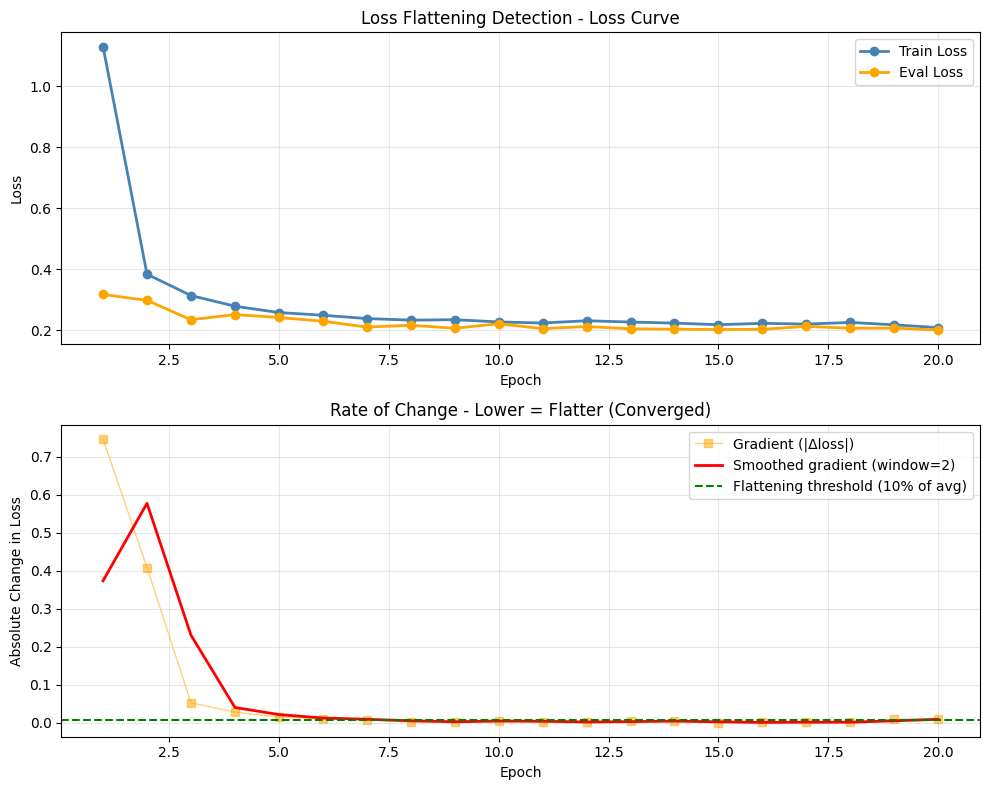


✓ Loss appears to flatten starting around epoch 8


In [4]:
from graphs import plot_loss_flattening
plot_loss_flattening(train_losses, eval_losses, window_size=2)

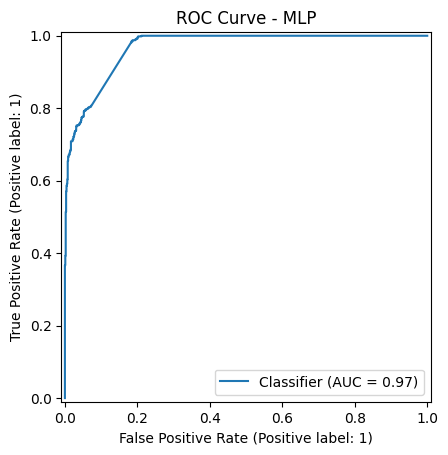

In [5]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(eval_labels, eval_preds)
plt.title("ROC Curve - MLP")
plt.show()

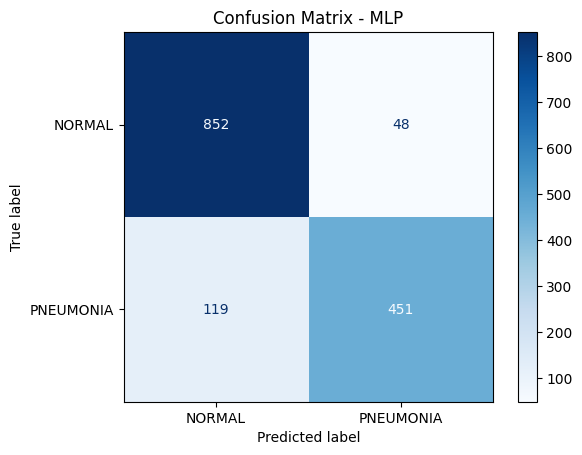

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(eval_labels, eval_preds.round(), display_labels=["NORMAL", "PNEUMONIA"], cmap="Blues")
plt.title("Confusion Matrix - MLP")
plt.show()